In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer

In [2]:
df = pd.read_parquet("../data/03_feature/engineered_data.parquet")
df.head()

Price,Date,Ticker,Open,High,Low,Close,Volume,return_lag_1,return_lag_5,return_lag_10,...,lower_shadow_pct,volume_pct_change,relative_volume_30,volume_sma_20,return_x_volume,drawdown_30,rolling_window_mdd_30,sharpe_30,day_of_week,month
0,2015-01-02,GOOG,26.147542,26.259249,25.904854,25.939947,28951268,NaN,NaN,NaN,...,0.001353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Friday,01
1,2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,NaN,NaN,NaN,...,0.015897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Friday,01
2,2015-01-02,AAPL,24.648443,24.659508,23.754470,24.192606,212818400,NaN,NaN,NaN,...,0.018110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Friday,01
3,2015-01-02,MSFT,39.596890,40.241844,39.495056,39.681751,27913900,NaN,NaN,NaN,...,0.002566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Friday,01
4,2015-01-05,GOOG,25.863334,25.916222,25.359177,25.399212,41196796,-0.020846,NaN,NaN,...,0.001576,0.42297,NaN,NaN,-2.227656e+07,NaN,NaN,NaN,Monday,01


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 11064 entries, 0 to 11063
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11064 non-null  datetime64[ms]
 1   Ticker                       11064 non-null  str           
 2   Open                         11064 non-null  float64       
 3   High                         11064 non-null  float64       
 4   Low                          11064 non-null  float64       
 5   Close                        11064 non-null  float64       
 6   Volume                       11064 non-null  int64         
 7   return_lag_1                 11060 non-null  float64       
 8   return_lag_5                 11044 non-null  float64       
 9   return_lag_10                11024 non-null  float64       
 10  return_lag_20                10984 non-null  float64       
 11  log_return_lag_1             11060 non-null  float64     

In [4]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Remove missing values from dataframe."""
    
    return df.dropna()

In [5]:
cleaned_data = clean_data(df)
print(cleaned_data.head())

Price       Date Ticker       Open       High        Low      Close  \
240   2015-03-31   GOOG  27.185021  27.417824  27.022899  27.086166   
241   2015-03-31   NVDA   0.515074   0.515556   0.503046   0.503527   
242   2015-03-31   AAPL  28.011387  28.100249  27.627062  27.642612   
243   2015-03-31   MSFT  34.853234  35.066900  34.648116  34.750675   
246   2015-04-01   AAPL  27.729239  27.795886  27.347134  27.602612   

Price     Volume  return_lag_1  return_lag_5  return_lag_10  ...  \
240     31760961     -0.007300     -0.038917      -0.005156  ...   
241    357276000     -0.025151     -0.065625      -0.099785  ...   
242    168362400     -0.015351     -0.017839      -0.020544  ...   
243     34887200     -0.007325     -0.052215      -0.024940  ...   
246    162485600     -0.001447      0.007051      -0.032848  ...   

Price  lower_shadow_pct  volume_pct_change  relative_volume_30  volume_sma_20  \
240            0.002336           0.233411            0.924254   3.481422e+07   
24

In [6]:
print(cleaned_data.info())

<class 'pandas.DataFrame'>
Index: 10824 entries, 240 to 11063
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         10824 non-null  datetime64[ms]
 1   Ticker                       10824 non-null  str           
 2   Open                         10824 non-null  float64       
 3   High                         10824 non-null  float64       
 4   Low                          10824 non-null  float64       
 5   Close                        10824 non-null  float64       
 6   Volume                       10824 non-null  int64         
 7   return_lag_1                 10824 non-null  float64       
 8   return_lag_5                 10824 non-null  float64       
 9   return_lag_10                10824 non-null  float64       
 10  return_lag_20                10824 non-null  float64       
 11  log_return_lag_1             10824 non-null  float64   

array([[<Axes: title={'center': 'Date'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>,
        <Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>,
        <Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'return_lag_1'}>],
       [<Axes: title={'center': 'return_lag_5'}>,
        <Axes: title={'center': 'return_lag_10'}>,
        <Axes: title={'center': 'return_lag_20'}>,
        <Axes: title={'center': 'log_return_lag_1'}>,
        <Axes: title={'center': 'SMA_5'}>,
        <Axes: title={'center': 'SMA_20'}>,
        <Axes: title={'center': 'SMA_50'}>],
       [<Axes: title={'center': 'ema_12'}>,
        <Axes: title={'center': 'ema_26'}>,
        <Axes: title={'center': 'close_vs_SMA_20'}>,
        <Axes: title={'center': 'rsi_14'}>,
        <Axes: title={'center': 'momentum_5'}>,
        <Axes: title={'center': 'momentum_20'}>,
        <Axes: title={'center': 'momentum_60'}>],
       [<Axes: title={'ce

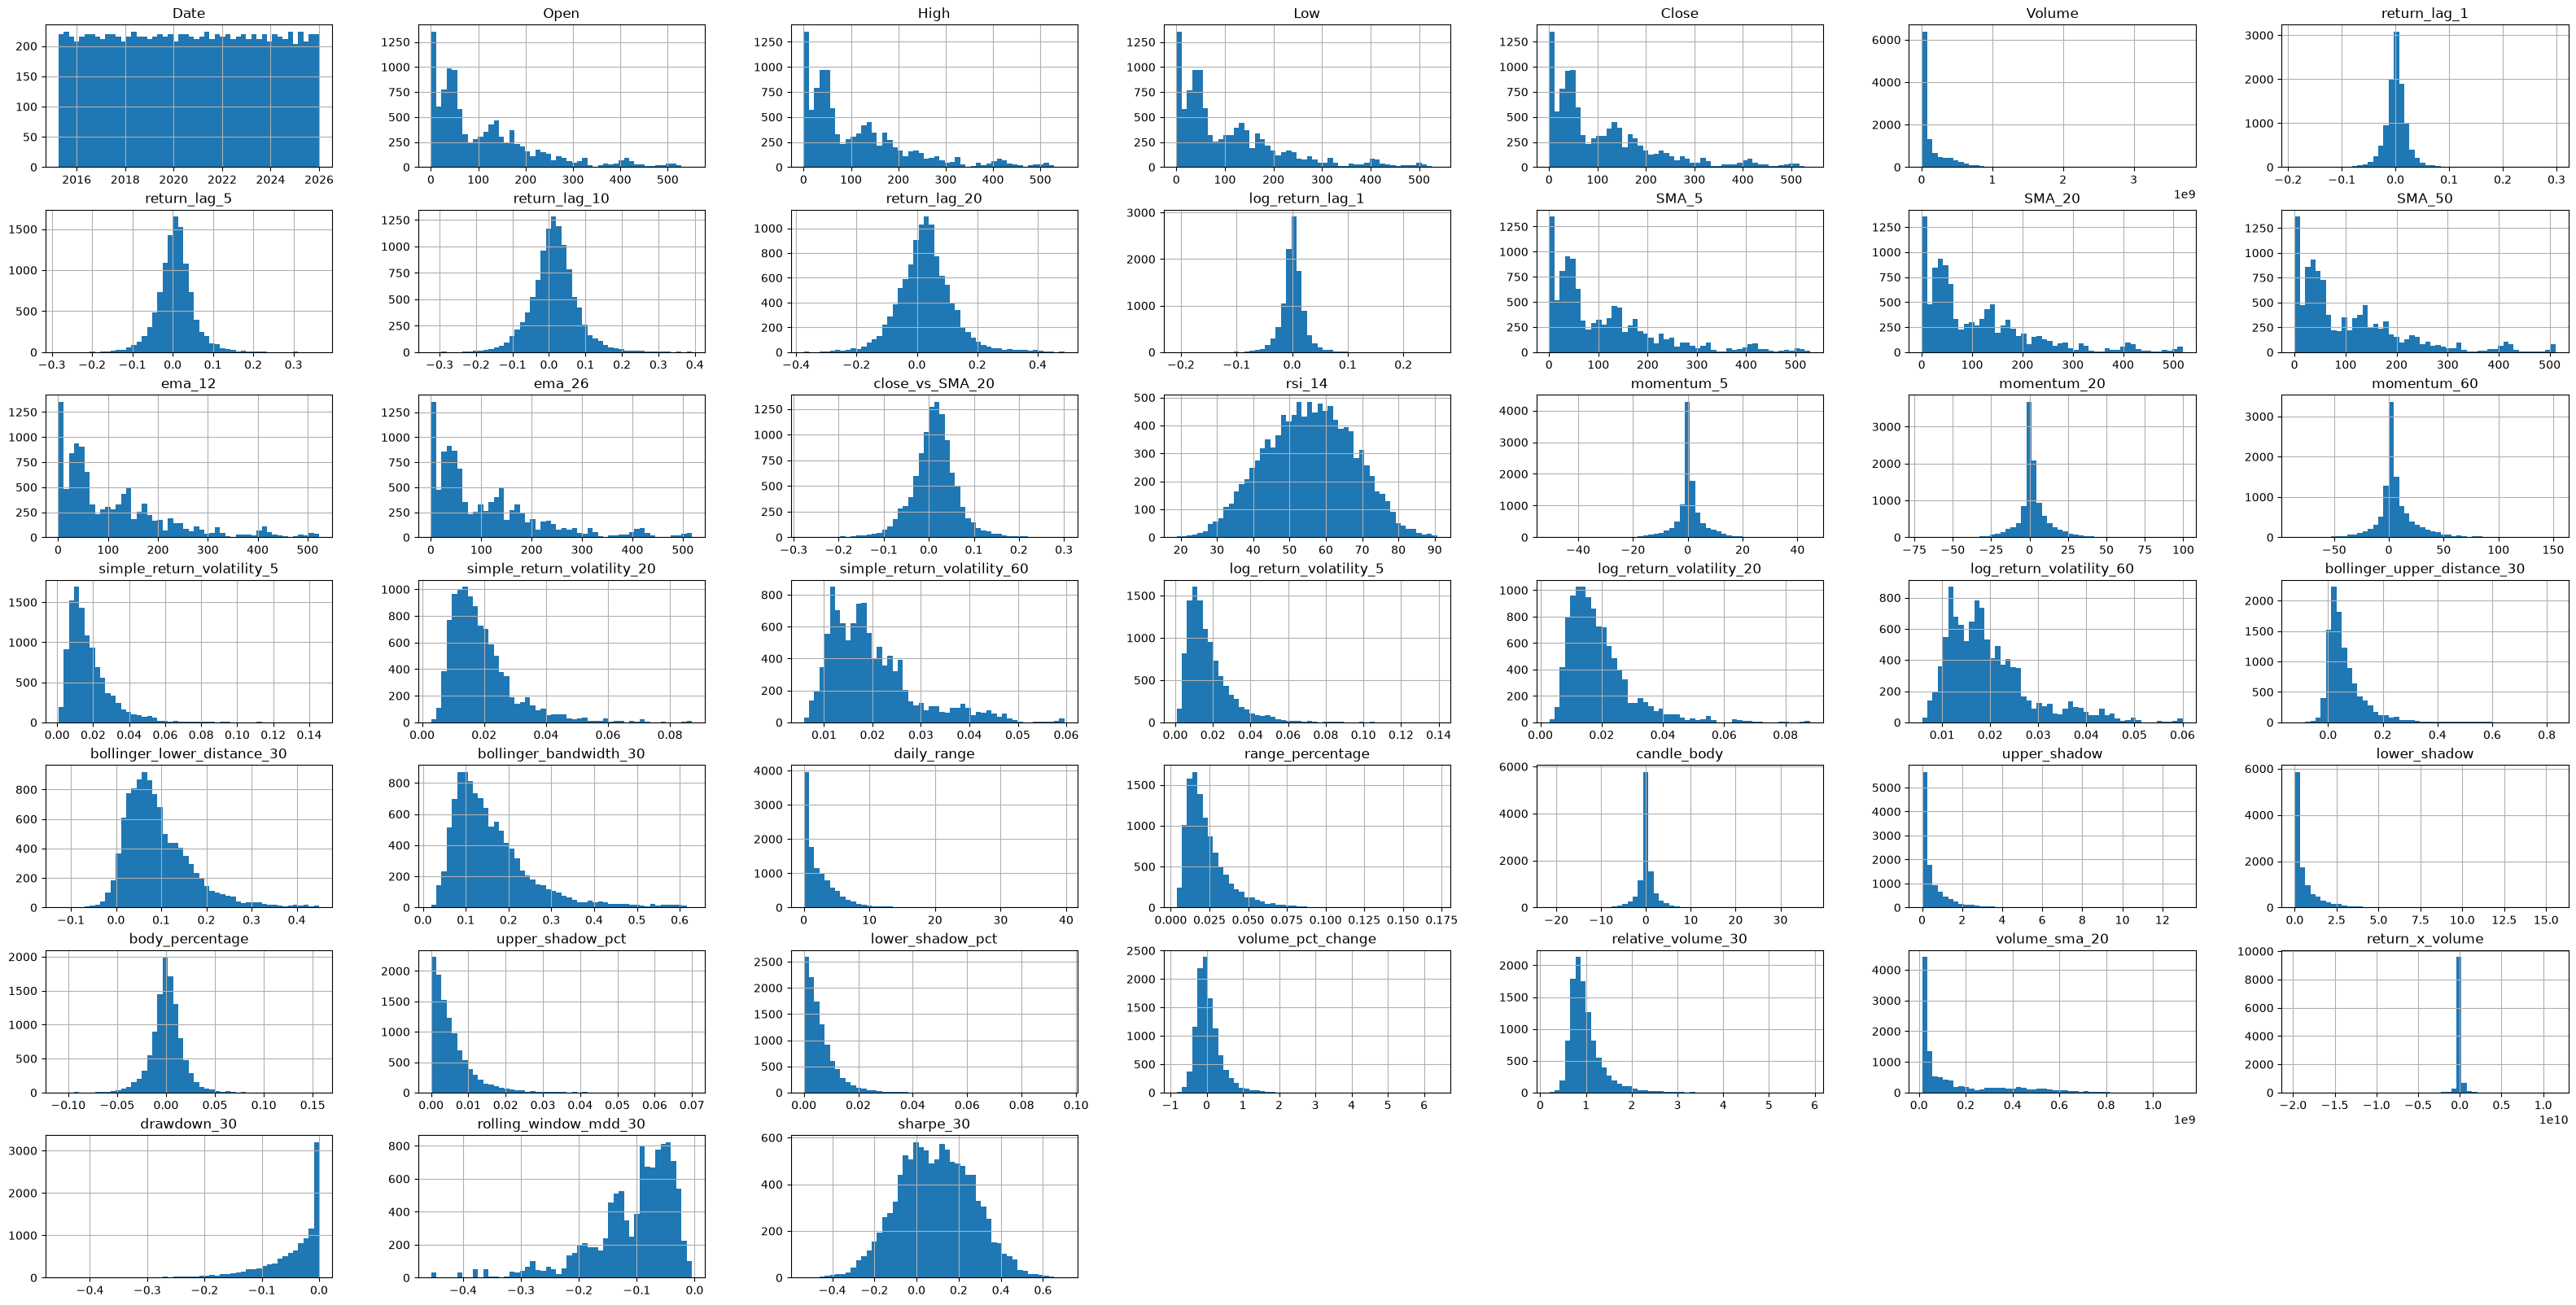

In [7]:
cleaned_data.iloc[:].hist(bins=50, figsize=(40,20))

array([[<Axes: title={'center': 'Date'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>,
        <Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>,
        <Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'return_lag_1'}>],
       [<Axes: title={'center': 'return_lag_5'}>,
        <Axes: title={'center': 'return_lag_10'}>,
        <Axes: title={'center': 'return_lag_20'}>,
        <Axes: title={'center': 'log_return_lag_1'}>,
        <Axes: title={'center': 'SMA_5'}>,
        <Axes: title={'center': 'SMA_20'}>,
        <Axes: title={'center': 'SMA_50'}>],
       [<Axes: title={'center': 'ema_12'}>,
        <Axes: title={'center': 'ema_26'}>,
        <Axes: title={'center': 'close_vs_SMA_20'}>,
        <Axes: title={'center': 'rsi_14'}>,
        <Axes: title={'center': 'momentum_5'}>,
        <Axes: title={'center': 'momentum_20'}>,
        <Axes: title={'center': 'momentum_60'}>],
       [<Axes: title={'ce

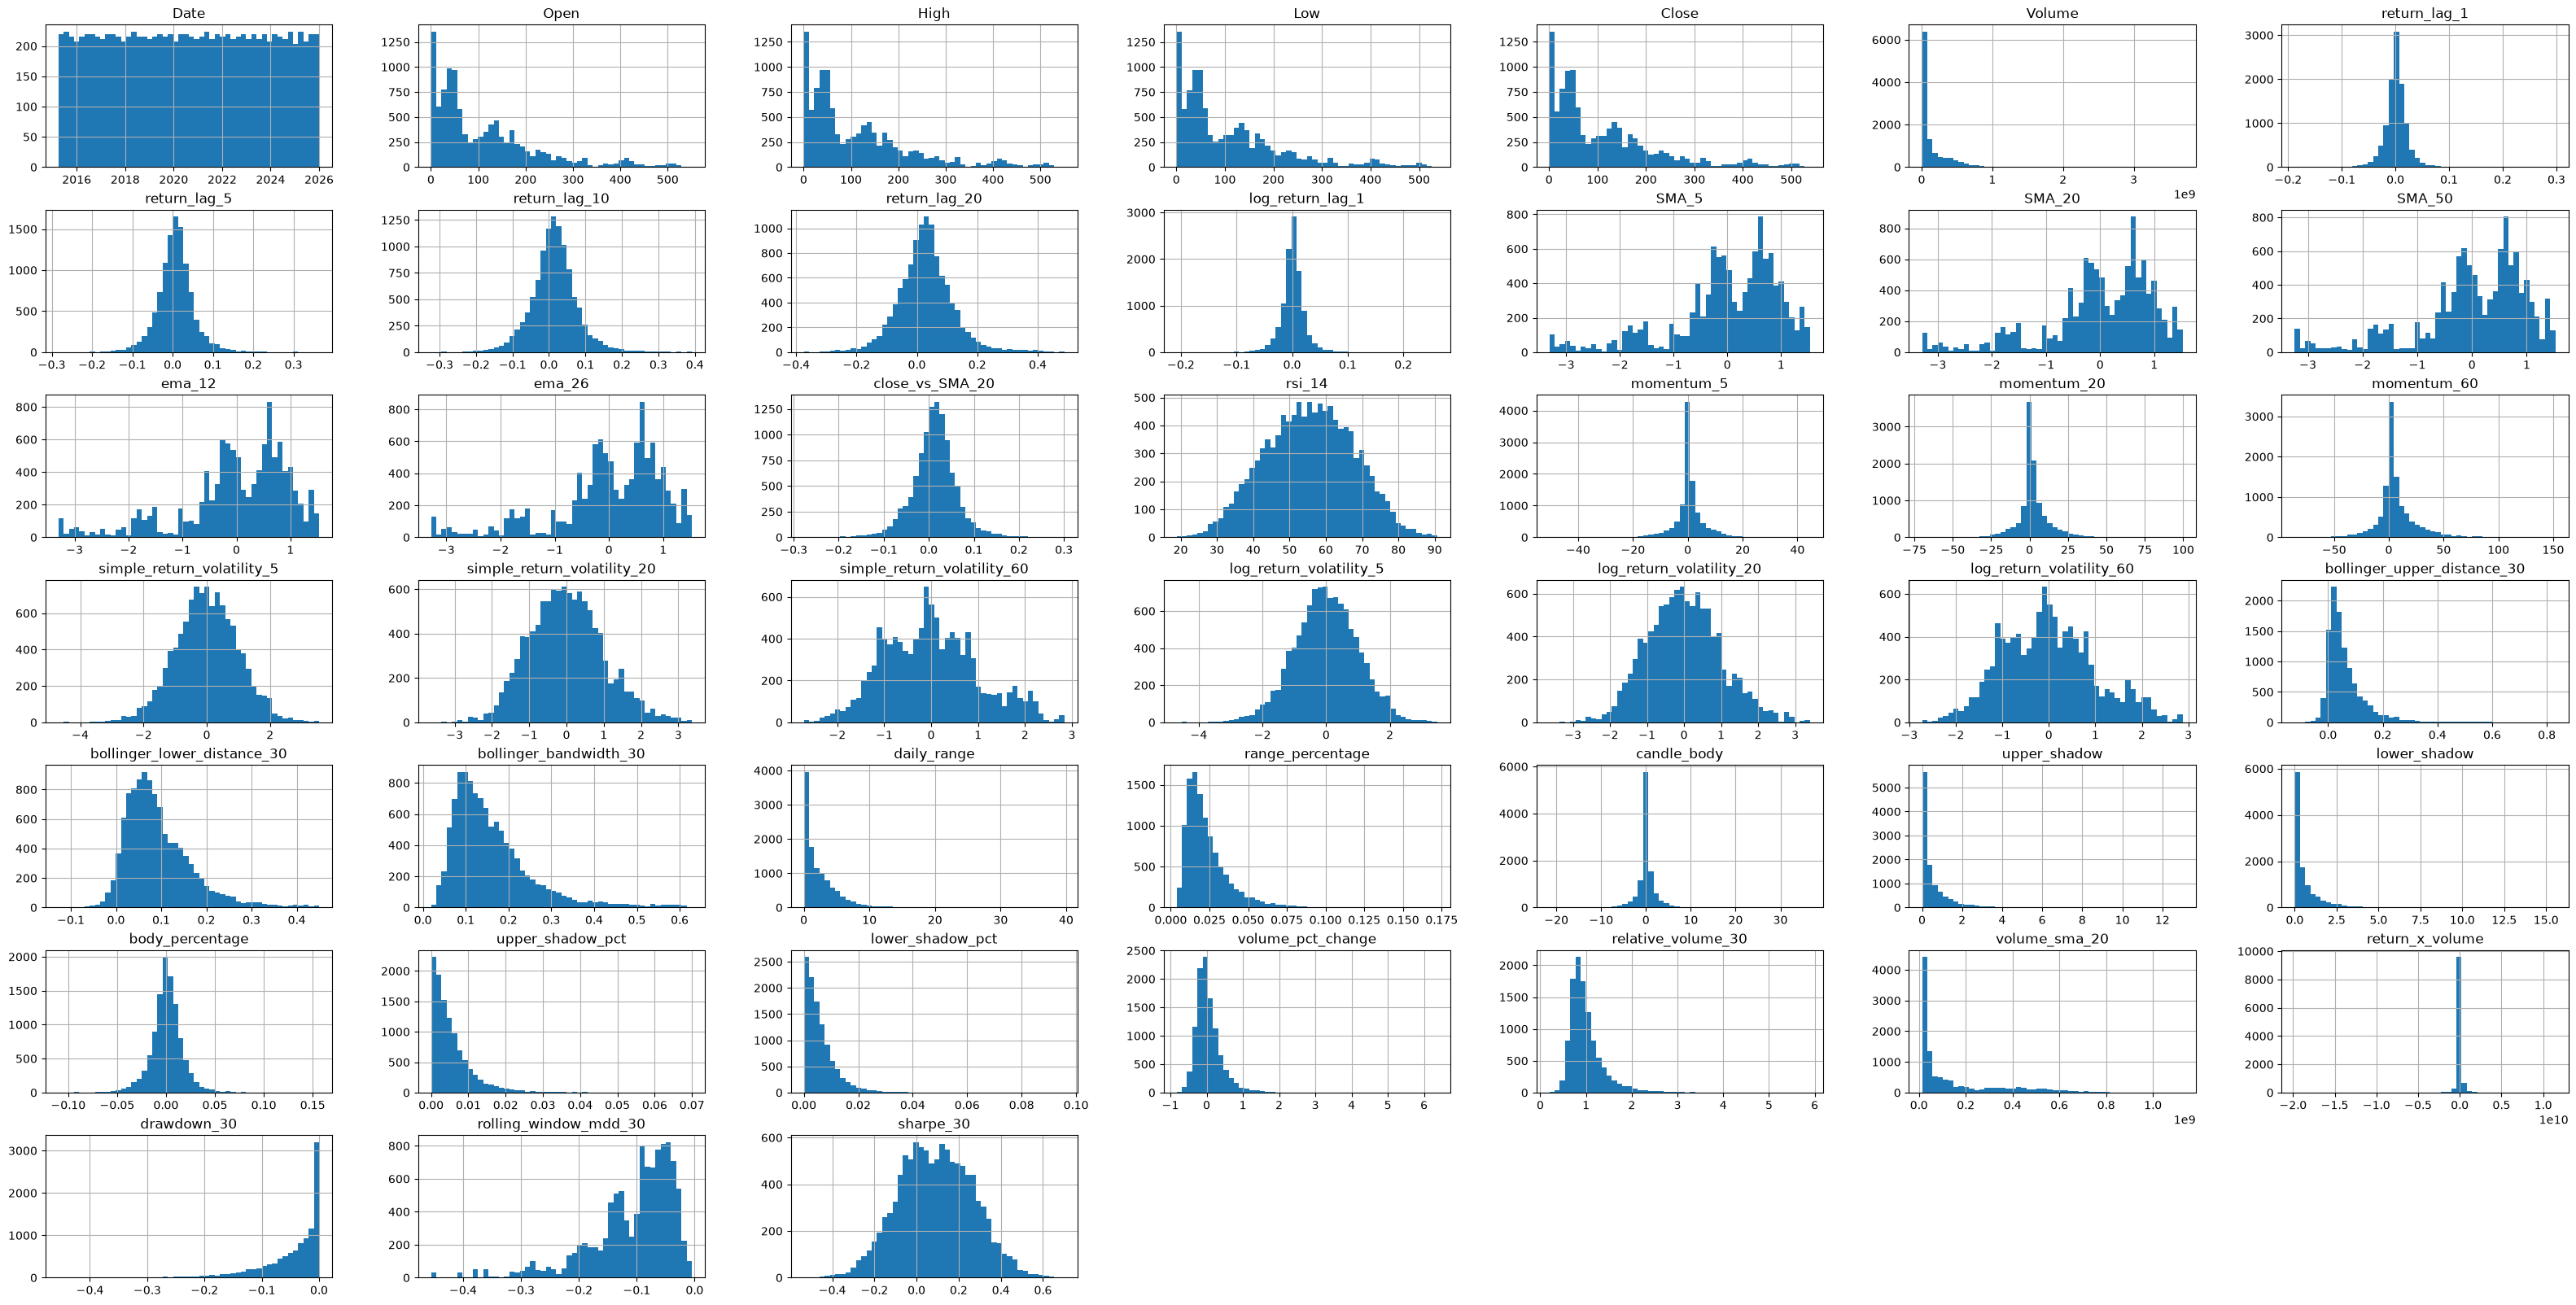

In [35]:
log_transformed_data = cleaned_data.copy()
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler(feature_range=(-1,1))
qt = QuantileTransformer(output_distribution='normal', random_state=42)
#log_transformed_data["Open"] = min_max_scaler.fit_transform(np.log(log_transformed_data[["Open"]]))
#log_transformed_data["Close"] = np.log(log_transformed_data["Close"])
#log_transformed_data["High"] = np.log(log_transformed_data["High"])
#log_transformed_data["Low"] = np.log(log_transformed_data["Low"])
#log_transformed_data["Volume"] = np.log(log_transformed_data["Volume"])
log_transformed_data["SMA_5"] = std_scaler.fit_transform(np.log(log_transformed_data[["SMA_5"]]))
log_transformed_data["SMA_20"] = std_scaler.fit_transform(np.log(log_transformed_data[["SMA_20"]]))
log_transformed_data["SMA_50"] = std_scaler.fit_transform(np.log(log_transformed_data[["SMA_50"]]))
log_transformed_data["ema_12"] = std_scaler.fit_transform(np.log(log_transformed_data[["ema_12"]]))
log_transformed_data["ema_26"] = std_scaler.fit_transform(np.log(log_transformed_data[["ema_26"]]))
log_transformed_data["simple_return_volatility_5"] = std_scaler.fit_transform(np.log(log_transformed_data[["simple_return_volatility_5"]]))
log_transformed_data["simple_return_volatility_20"] = std_scaler.fit_transform(np.log(log_transformed_data[["simple_return_volatility_20"]]))
log_transformed_data["simple_return_volatility_60"] = std_scaler.fit_transform(np.log(log_transformed_data[["simple_return_volatility_60"]]))
log_transformed_data["log_return_volatility_5"] = std_scaler.fit_transform(np.log(log_transformed_data[["log_return_volatility_5"]]))
log_transformed_data["log_return_volatility_20"] = std_scaler.fit_transform(np.log(log_transformed_data[["log_return_volatility_20"]]))
log_transformed_data["log_return_volatility_60"] = std_scaler.fit_transform(np.log(log_transformed_data[["log_return_volatility_60"]]))
log_transformed_data.iloc[:].hist(bins=50, figsize=(40,20))